# House Price Prediction - BetaBytez AI/ML Internship Task 3
# Name: Sabiha Metlo
## Dataset: House Prices - Advanced Regression Techniques
**Domain:** Real Estate
**Goal:** Predicts the sale price of a house (regression) based on its features (e.g., size, location, condition, age).
**Target Column:** SalePrice
---
## Section 1: Setup & Data Loading

In [1]:
import os 
os.chdir(r'C:\Users\metlo\OneDrive\Desktop\betabytez-aiml-task3-sabiha')
print("Working directory:", os.getcwd())

Working directory: C:\Users\metlo\OneDrive\Desktop\betabytez-aiml-task3-sabiha


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load Dataset
df = pd.read_csv('model/train.csv')

print("\nFirst 5 rows")
df.head()


First 5 rows


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Basic Dataset Information
print("=== Dataset shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n=== DataTypes ===")
print(df.info())


=== Dataset shape ===
Rows: 1460, Columns: 81

=== DataTypes ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   

In [5]:
# Fill Nan Values
fill_Nan_values = ["Alley", "PoolQC", "Fence", "MiscFeature", "FireplaceQu"]
df[fill_Nan_values] = df[fill_Nan_values].fillna("None")

print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
df[fill_Nan_values] = df[fill_Nan_values].fillna("None")
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

pd.set_option('display.max_rows', None)
print(df.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
Street             0
Alley              0
LotShape           0
LandContour        0
Utilities          0
LotConfig          0
LandSlope          0
Neighborhood       0
Condition1         0
Condition2         0
BldgType           0
HouseStyle         0
OverallQual        0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
RoofStyle          0
RoofMatl           0
Exterior1st        0
Exterior2nd        0
MasVnrType       872
MasVnrArea         8
ExterQual          0
ExterCond          0
Foundation         0
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinSF1         0
BsmtFinType2      38
BsmtFinSF2         0
BsmtUnfSF          0
TotalBsmtSF        0
Heating            0
HeatingQC          0
CentralAir         0
Electrical         1
1stFlrSF           0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath 

In [7]:
# Step: Handle "NaN = No Feature" Columns
columns_none = ["Alley", "PoolQC", "Fence", "MiscFeature", "FireplaceQu"]

df[columns_none] = df[columns_none].fillna("None")

print(df.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
Street             0
Alley              0
LotShape           0
LandContour        0
Utilities          0
LotConfig          0
LandSlope          0
Neighborhood       0
Condition1         0
Condition2         0
BldgType           0
HouseStyle         0
OverallQual        0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
RoofStyle          0
RoofMatl           0
Exterior1st        0
Exterior2nd        0
MasVnrType       872
MasVnrArea         8
ExterQual          0
ExterCond          0
Foundation         0
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinSF1         0
BsmtFinType2      38
BsmtFinSF2         0
BsmtUnfSF          0
TotalBsmtSF        0
Heating            0
HeatingQC          0
CentralAir         0
Electrical         1
1stFlrSF           0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath 

In [8]:
# Handle "NaN = No Feature" — Basement, Garage, Masonry Columns
columns_none_group2 = [
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "MasVnrType"
]

df[columns_none_group2] = df[columns_none_group2].fillna("None")

print(df.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
Street             0
Alley              0
LotShape           0
LandContour        0
Utilities          0
LotConfig          0
LandSlope          0
Neighborhood       0
Condition1         0
Condition2         0
BldgType           0
HouseStyle         0
OverallQual        0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
RoofStyle          0
RoofMatl           0
Exterior1st        0
Exterior2nd        0
MasVnrType         0
MasVnrArea         8
ExterQual          0
ExterCond          0
Foundation         0
BsmtQual           0
BsmtCond           0
BsmtExposure       0
BsmtFinType1       0
BsmtFinSF1         0
BsmtFinType2       0
BsmtFinSF2         0
BsmtUnfSF          0
TotalBsmtSF        0
Heating            0
HeatingQC          0
CentralAir         0
Electrical         1
1stFlrSF           0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath 

In [9]:
# Handle Genuinely Missing Values

df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

print(df.isnull().sum().sum())  # should print 0 if everything is handled

0


## Step: Explore Target Variable Distribution (SalePrice)

Before modeling, we check whether SalePrice is normally distributed or skewed.
A skewed target can bias regression models toward extreme values.

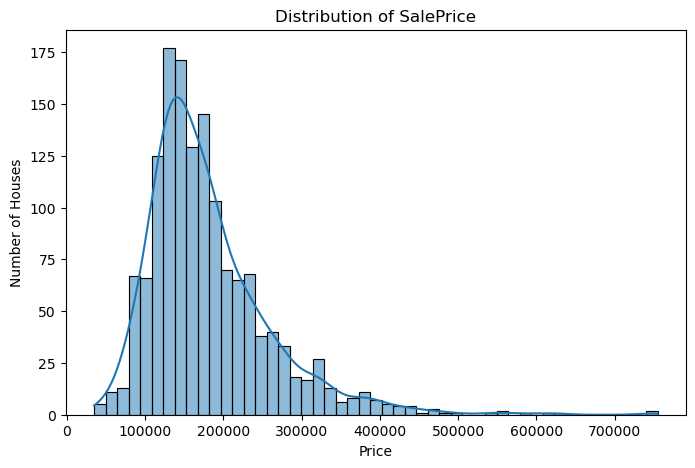

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], kde=True)

plt.title("Distribution of SalePrice") 
plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.show()

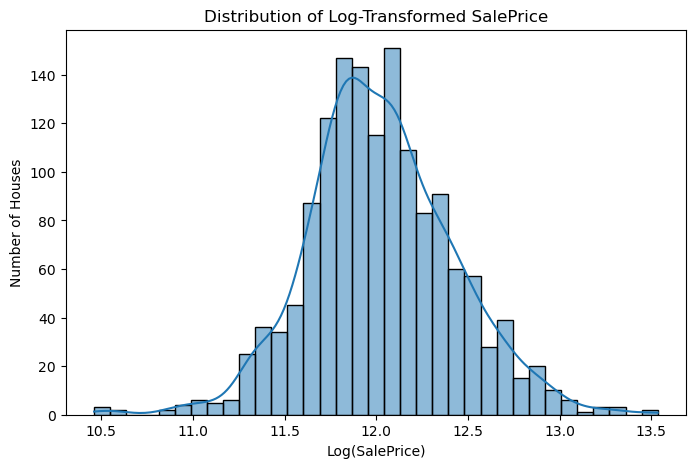

In [11]:
## Step: Log-Transform SalePrice to Reduce Skew
df["SalePrice_log"] = np.log1p(df["SalePrice"])

plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice_log"], kde=True)
plt.title("Distribution of Log-Transformed SalePrice")
plt.xlabel("Log(SalePrice)")
plt.ylabel("Number of Houses")
plt.show()